# X-Ray Classification - FULLY OPTIMIZED Training V2
## Improvements from V1:
- Early Stopping patience: 7 (was 3)
- Phase 2 epochs: 25 (was 12)
- Mixup/CutMix probability: 30% (was 100%)
- Focal Loss gamma: 1.5 (was 2)
- Phase 2 base LR: 1e-4 (was 5e-5)
- Added Label Smoothing (0.1)

# 1. IMPORTS & CONFIG

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

✅ Device: cuda


# 2. DATASET PREPARATION

In [2]:
DATA_DIR = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
classes = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

paths, labels = [], []

for label_idx, cls in enumerate(classes):
    folder = os.path.join(DATA_DIR, cls, "images")
    if not os.path.exists(folder):
        print(f"⚠️ Folder not found: {folder}")
        continue

    for img_name in os.listdir(folder):
        if img_name.lower().endswith(".png"):
            paths.append(os.path.join(folder, img_name))
            labels.append(label_idx)

df = pd.DataFrame({"image": paths, "label": labels})
print("📊 Class distribution:")
print(df["label"].value_counts())
print(f"\n📁 Total images: {len(df)}")

📊 Class distribution:
label
1    10192
3     6012
0     3616
2     1345
Name: count, dtype: int64

📁 Total images: 21165


# 3. TRAIN/VAL/TEST SPLIT (80/10/10)

In [3]:
# Step 1: Split into train (80%) and temp (20%)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.25,
    stratify=df["label"], 
    random_state=42
)

# Step 2: Split temp into val (10%) and test (10%)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.40,
    stratify=temp_df["label"], 
    random_state=42
)

print(f"📊 Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"📊 Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"📊 Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

📊 Train: 15873 (75.0%)
📊 Val: 3175 (15.0%)
📊 Test: 2117 (10.0%)


# 4. ENHANCED TRANSFORMS

In [4]:
# Strong augmentation for training
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

# Simple transforms for validation/test
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Enhanced TTA transforms
tta_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 5. FOCAL LOSS WITH LABEL SMOOTHING

In [5]:
class FocalLossWithSmoothing(nn.Module):
    """Focal Loss with Label Smoothing - focuses on hard samples"""
    def __init__(self, alpha=None, gamma=1.5, smoothing=0.1, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma  # REDUCED from 2 to 1.5
        self.smoothing = smoothing  # NEW: label smoothing
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets, 
            weight=self.alpha, 
            reduction='none',
            label_smoothing=self.smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

print("✅ Focal Loss with Label Smoothing defined (gamma=1.5, smoothing=0.1)")

✅ Focal Loss with Label Smoothing defined (gamma=1.5, smoothing=0.1)


# 6. DATASET CLASS WITH MIXUP + CUTMIX

In [6]:
class ChestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]
        img = Image.open(img_path).convert("RGB")
        if self.transform: 
            img = self.transform(img)
        return img, label


# Mixup function
def mixup_data(x, y, alpha=0.2):
    """Apply Mixup augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


# CutMix function
def rand_bbox(size, lam):
    """Generate random bounding box for CutMix"""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2


def cutmix_data(x, y, alpha=1.0):
    """Apply CutMix augmentation"""
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(x.device)
    
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    
    # Adjust lambda based on actual area
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
    
    return x, y, y[rand_index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup/CutMix loss function"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# Create datasets
train_ds = ChestDataset(train_df, train_tfms)
val_ds = ChestDataset(val_df, val_tfms)
test_ds = ChestDataset(test_df, val_tfms)

print(f"✅ Datasets created")

✅ Datasets created


# 7. WEIGHTED RANDOM SAMPLER (Class Balancing)

In [7]:
# Compute class weights
weights = compute_class_weight(
    'balanced', 
    classes=np.unique(df["label"]), 
    y=df["label"]
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("⚖️ Class weights:", class_weights)

# Create sample weights for WeightedRandomSampler
train_labels = train_df['label'].values
sample_weights = [weights[label] for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=26, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=26, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=26, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders with WeightedRandomSampler created")

⚖️ Class weights: tensor([1.4633, 0.5192, 3.9340, 0.8801], device='cuda:0')
✅ DataLoaders with WeightedRandomSampler created


# 8. MODEL WITH LLRD

In [8]:
# Load EfficientNet V2 Large with pretrained weights
model = models.efficientnet_v2_l(weights='IMAGENET1K_V1')

# Modify classifier for 4 classes
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, len(classes))
)

model = model.to(device)

# Focal Loss with Label Smoothing and reduced gamma
criterion = FocalLossWithSmoothing(alpha=class_weights, gamma=1.5, smoothing=0.1)


def get_optimizer_with_llrd(model, base_lr=1e-4, decay_factor=0.9):
    """
    Layer-wise Learning Rate Decay
    Earlier layers get smaller learning rates
    """
    parameters = []
    num_layers = len(model.features)
    
    for i, layer in enumerate(model.features):
        lr = base_lr * (decay_factor ** (num_layers - i - 1))
        parameters.append({'params': layer.parameters(), 'lr': lr})
    
    # Classifier gets full learning rate
    parameters.append({'params': model.classifier.parameters(), 'lr': base_lr})
    
    return optim.AdamW(parameters, weight_decay=1e-4)


# Create optimizer with LLRD
optimizer = get_optimizer_with_llrd(model, base_lr=1e-4, decay_factor=0.85)

# Cosine Annealing Scheduler with Warm Restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-7
)

print("✅ EfficientNet V2 Large loaded with LLRD and Focal Loss (gamma=1.5, smoothing=0.1)")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_l-59c71312.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_l-59c71312.pth


100%|██████████| 455M/455M [00:18<00:00, 25.1MB/s] 


✅ EfficientNet V2 Large loaded with LLRD and Focal Loss (gamma=1.5, smoothing=0.1)


# 9. TRAINING FUNCTIONS WITH REDUCED MIXUP/CUTMIX

In [9]:
# Config
ACCUMULATION_STEPS = 2  # Effective batch size = 16 * 2 = 32
MIXUP_CUTMIX_PROB = 0.3  # REDUCED: Apply Mixup/CutMix only 30% of time


def train_one_epoch(model, loader, criterion, optimizer, scheduler,
                    use_mixup=True, use_cutmix=True, mixup_alpha=0.2, cutmix_alpha=1.0,
                    mix_prob=0.3, accumulation_steps=2):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    optimizer.zero_grad()
    
    for batch_idx, (imgs, labels) in enumerate(tqdm(loader, desc="Train", leave=False)):
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Apply Mixup/CutMix only with mix_prob probability
        use_mix = False
        if (use_mixup or use_cutmix) and np.random.rand() < mix_prob:
            use_mix = True
            r = np.random.rand()
            if r < 0.5 and use_cutmix:
                imgs, y_a, y_b, lam = cutmix_data(imgs.clone(), labels, alpha=cutmix_alpha)
            elif use_mixup:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            else:
                use_mix = False
        
        outputs = model(imgs)
        
        if use_mix:
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            loss = criterion(outputs, labels)
        
        # Scale loss for gradient accumulation
        loss = loss / accumulation_steps
        loss.backward()
        
        # Gradient clipping
        if (batch_idx + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # Handle remaining gradients
    if (batch_idx + 1) % accumulation_steps != 0:
        optimizer.step()
        optimizer.zero_grad()
    
    scheduler.step()
    
    avg_loss = total_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, f1


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Val", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    
    return avg_loss, accuracy, f1, f1_per_class

# 10. PHASE 1 - WARM-UP (No Mixup/CutMix)

In [10]:
print("🚀 Phase 1: Warm-up Training (5 epochs, No Mixup/CutMix)")
print("="*70)

# Freeze early layers for warm-up
for param in model.features[:5].parameters():
    param.requires_grad = False

best_f1 = 0
early_stop_patience = 7  # INCREASED from 3
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}

for epoch in range(5):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler,
        use_mixup=False, use_cutmix=False,
        accumulation_steps=ACCUMULATION_STEPS
    )
    val_loss, val_acc, val_f1, val_f1_per_class = validate(model, val_loader, criterion)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    print(f"[Phase 1] Epoch {epoch+1}/5 | Train Acc: {train_acc:.3f} F1: {train_f1:.3f} | Val Acc: {val_acc:.3f} F1: {val_f1:.3f}")
    print(f"         Per-class F1: COVID={val_f1_per_class[0]:.3f}, Normal={val_f1_per_class[1]:.3f}, VP={val_f1_per_class[2]:.3f}, LO={val_f1_per_class[3]:.3f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), "best_effv2l_optimized_v2.pth")
        print("💾 Saved best model!")
    else:
        no_improve += 1

🚀 Phase 1: Warm-up Training (5 epochs, No Mixup/CutMix)


[Phase 1] Epoch 1/5 | Train Acc: 0.740 F1: 0.724 | Val Acc: 0.868 F1: 0.863
         Per-class F1: COVID=0.823, Normal=0.880, VP=0.870, LO=0.877
💾 Saved best model!


[Phase 1] Epoch 2/5 | Train Acc: 0.879 F1: 0.874 | Val Acc: 0.911 F1: 0.915
         Per-class F1: COVID=0.903, Normal=0.918, VP=0.941, LO=0.899
💾 Saved best model!


[Phase 1] Epoch 3/5 | Train Acc: 0.909 F1: 0.907 | Val Acc: 0.921 F1: 0.925
         Per-class F1: COVID=0.913, Normal=0.928, VP=0.949, LO=0.908
💾 Saved best model!


[Phase 1] Epoch 4/5 | Train Acc: 0.923 F1: 0.922 | Val Acc: 0.933 F1: 0.936
         Per-class F1: COVID=0.932, Normal=0.939, VP=0.952, LO=0.921
💾 Saved best model!


[Phase 1] Epoch 5/5 | Train Acc: 0.935 F1: 0.934 | Val Acc: 0.940 F1: 0.945
         Per-class F1: COVID=0.952, Normal=0.946, VP=0.965, LO=0.919
💾 Saved best model!


# 11. PHASE 2 - FULL FINE-TUNING (30% Mixup/CutMix)

In [11]:
print("\n🚀 Phase 2: Full Fine-Tuning (25 epochs, 30% Mixup + CutMix)")
print("="*70)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# New optimizer with LLRD and HIGHER learning rate (1e-4 instead of 5e-5)
optimizer = get_optimizer_with_llrd(model, base_lr=1e-4, decay_factor=0.85)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-8
)

no_improve = 0

for epoch in range(25):  # INCREASED from 12
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler,
        use_mixup=True, use_cutmix=True,
        mixup_alpha=0.2, cutmix_alpha=1.0,
        mix_prob=MIXUP_CUTMIX_PROB,  # Only 30% of time
        accumulation_steps=ACCUMULATION_STEPS
    )
    val_loss, val_acc, val_f1, val_f1_per_class = validate(model, val_loader, criterion)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    print(f"[Phase 2] Epoch {epoch+1}/25 | Train Acc: {train_acc:.3f} F1: {train_f1:.3f} | Val Acc: {val_acc:.3f} F1: {val_f1:.3f}")
    print(f"         Per-class F1: COVID={val_f1_per_class[0]:.3f}, Normal={val_f1_per_class[1]:.3f}, VP={val_f1_per_class[2]:.3f}, LO={val_f1_per_class[3]:.3f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), "best_effv2l_optimized_v2.pth")
        print("💾 Saved best model!")
    else:
        no_improve += 1
        if no_improve >= early_stop_patience:  # Now patience=7
            print(f"\n⚠️ Early stopping triggered after {early_stop_patience} epochs without improvement")
            break


🚀 Phase 2: Full Fine-Tuning (25 epochs, 30% Mixup + CutMix)


[Phase 2] Epoch 1/25 | Train Acc: 0.840 F1: 0.837 | Val Acc: 0.935 F1: 0.939
         Per-class F1: COVID=0.939, Normal=0.944, VP=0.961, LO=0.911


[Phase 2] Epoch 2/25 | Train Acc: 0.848 F1: 0.846 | Val Acc: 0.935 F1: 0.939
         Per-class F1: COVID=0.933, Normal=0.938, VP=0.959, LO=0.927


[Phase 2] Epoch 3/25 | Train Acc: 0.862 F1: 0.861 | Val Acc: 0.943 F1: 0.946
         Per-class F1: COVID=0.956, Normal=0.948, VP=0.956, LO=0.924
💾 Saved best model!


[Phase 2] Epoch 4/25 | Train Acc: 0.881 F1: 0.880 | Val Acc: 0.931 F1: 0.935
         Per-class F1: COVID=0.922, Normal=0.933, VP=0.956, LO=0.928


...

[Phase 2] Epoch 18/25 | Train Acc: 0.869 F1: 0.868 | Val Acc: 0.951 F1: 0.958
         Per-class F1: COVID=0.970, Normal=0.957, VP=0.980, LO=0.924


[Phase 2] Epoch 19/25 | Train Acc: 0.872 F1: 0.871 | Val Acc: 0.949 F1: 0.956
         Per-class F1: COVID=0.971, Normal=0.951, VP=0.973, LO=0.928


[Phase 2] Epoch 20/25 | Train Acc: 0.881 F1: 0.880 | Val Acc: 0.956 F1: 0.960
         Per-class F1: COVID=0.969, Normal=0.961, VP=0.975, LO=0.934


[Phase 2] Epoch 21/25 | Train Acc: 0.874 F1: 0.873 | Val Acc: 0.947 F1: 0.951
         Per-class F1: COVID=0.956, Normal=0.951, VP=0.968, LO=0.931


[Phase 2] Epoch 22/25 | Train Acc: 0.875 F1: 0.874 | Val Acc: 0.953 F1: 0.957
         Per-class F1: COVID=0.970, Normal=0.958, VP=0.970, LO=0.932

⚠️ Early stopping triggered after 7 epochs without improvement


# 12. TRAINING CURVES

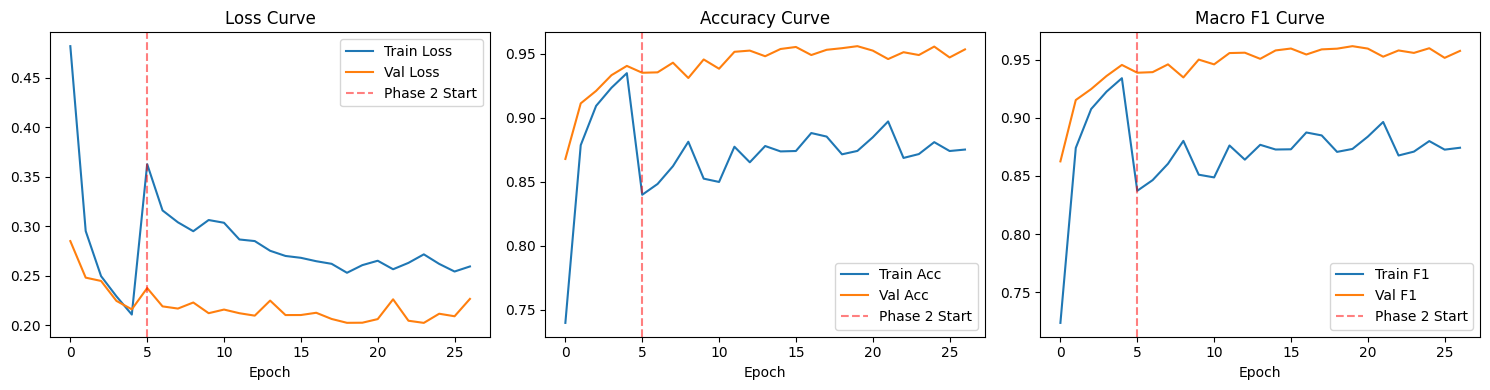

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].axvline(x=5, color='r', linestyle='--', alpha=0.5, label='Phase 2 Start')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].axvline(x=5, color='r', linestyle='--', alpha=0.5, label='Phase 2 Start')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# F1 curve
axes[2].plot(history['train_f1'], label='Train F1')
axes[2].plot(history['val_f1'], label='Val F1')
axes[2].axvline(x=5, color='r', linestyle='--', alpha=0.5, label='Phase 2 Start')
axes[2].set_title('Macro F1 Curve')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

# 13. ENHANCED TTA (10 augments)

In [13]:
class TTADataset(Dataset):
    """Dataset for Test Time Augmentation"""
    def __init__(self, df, transform, n_augments=10):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.n_augments = n_augments
    
    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]
        img = Image.open(img_path).convert("RGB")
        
        # Create multiple augmented versions
        imgs = [self.transform(img) for _ in range(self.n_augments)]
        return torch.stack(imgs), label


def evaluate_with_tta(model, df, n_augments=10):
    """Evaluate with Enhanced Test Time Augmentation"""
    model.eval()
    
    tta_dataset = TTADataset(df, tta_tfms, n_augments=n_augments)
    tta_loader = DataLoader(tta_dataset, batch_size=4, shuffle=False, num_workers=2)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs_batch, labels in tqdm(tta_loader, desc=f"TTA Eval ({n_augments} augments)"):
            batch_size = imgs_batch.size(0)
            n_aug = imgs_batch.size(1)
            
            # Reshape: [B, N, C, H, W] -> [B*N, C, H, W]
            imgs_flat = imgs_batch.view(-1, 3, 224, 224).to(device)
            
            # Get predictions
            outputs = model(imgs_flat)
            probs = F.softmax(outputs, dim=1)
            
            # Reshape back and average: [B*N, C] -> [B, N, C] -> [B, C]
            probs = probs.view(batch_size, n_aug, -1).mean(dim=1)
            
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_labels), np.array(all_preds)

# 14. FINAL EVALUATION ON TEST SET

In [14]:
# Load best model
model.load_state_dict(torch.load("best_effv2l_optimized_v2.pth"))
model.eval()

print("📊 FINAL EVALUATION ON TEST SET")
print("="*70)

# Standard evaluation
print("\n🔹 Standard Evaluation (No TTA):")
test_loss, test_acc, test_f1, test_f1_per_class = validate(model, test_loader, criterion)
print(f"   Accuracy: {test_acc:.4f}")
print(f"   Macro F1: {test_f1:.4f}")
print(f"   Per-class F1: COVID={test_f1_per_class[0]:.4f}, Normal={test_f1_per_class[1]:.4f}, VP={test_f1_per_class[2]:.4f}, LO={test_f1_per_class[3]:.4f}")

# TTA evaluation with 5 augments
print("\n🔹 TTA Evaluation (5 augments):")
y_true_tta5, y_pred_tta5 = evaluate_with_tta(model, test_df, n_augments=5)
tta5_acc = (y_true_tta5 == y_pred_tta5).mean()
tta5_f1 = f1_score(y_true_tta5, y_pred_tta5, average='macro')
tta5_f1_per_class = f1_score(y_true_tta5, y_pred_tta5, average=None)
print(f"   Accuracy: {tta5_acc:.4f}")
print(f"   Macro F1: {tta5_f1:.4f}")
print(f"   Per-class F1: COVID={tta5_f1_per_class[0]:.4f}, Normal={tta5_f1_per_class[1]:.4f}, VP={tta5_f1_per_class[2]:.4f}, LO={tta5_f1_per_class[3]:.4f}")

# TTA evaluation with 10 augments
print("\n🔹 TTA Evaluation (10 augments):")
y_true_tta, y_pred_tta = evaluate_with_tta(model, test_df, n_augments=10)
tta_acc = (y_true_tta == y_pred_tta).mean()
tta_f1 = f1_score(y_true_tta, y_pred_tta, average='macro')
tta_f1_per_class = f1_score(y_true_tta, y_pred_tta, average=None)
print(f"   Accuracy: {tta_acc:.4f}")
print(f"   Macro F1: {tta_f1:.4f}")
print(f"   Per-class F1: COVID={tta_f1_per_class[0]:.4f}, Normal={tta_f1_per_class[1]:.4f}, VP={tta_f1_per_class[2]:.4f}, LO={tta_f1_per_class[3]:.4f}")

📊 FINAL EVALUATION ON TEST SET

🔹 Standard Evaluation (No TTA):


   Accuracy: 0.9627
   Macro F1: 0.9676
   Per-class F1: COVID=0.9848, Normal=0.9627, VP=0.9771, LO=0.9459

🔹 TTA Evaluation (5 augments):


TTA Eval (5 augments): 100%|██████████| 530/530 [01:14<00:00,  7.09it/s]


   Accuracy: 0.9669
   Macro F1: 0.9734
   Per-class F1: COVID=0.9890, Normal=0.9667, VP=0.9888, LO=0.9491

🔹 TTA Evaluation (10 augments):


TTA Eval (10 augments): 100%|██████████| 530/530 [02:12<00:00,  4.00it/s]

   Accuracy: 0.9646
   Macro F1: 0.9709
   Per-class F1: COVID=0.9876, Normal=0.9641, VP=0.9852, LO=0.9468


# 15. CONFUSION MATRIX & CLASSIFICATION REPORT

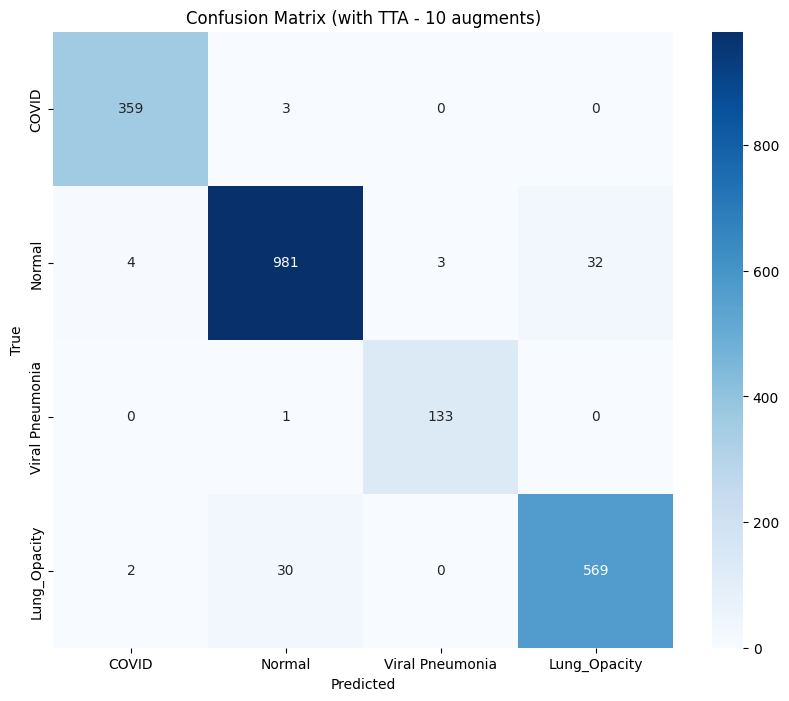


📋 CLASSIFICATION REPORT (with TTA - 10 augments):
                 precision    recall  f1-score   support

          COVID     0.9836    0.9917    0.9876       362
         Normal     0.9665    0.9618    0.9641      1020
Viral Pneumonia     0.9779    0.9925    0.9852       134
   Lung_Opacity     0.9468    0.9468    0.9468       601

       accuracy                         0.9646      2117
      macro avg     0.9687    0.9732    0.9709      2117
   weighted avg     0.9645    0.9646    0.9645      2117



In [15]:
# Plot confusion matrix for TTA results
cm = confusion_matrix(y_true_tta, y_pred_tta)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (with TTA - 10 augments)")
plt.show()

# Classification report
print("\n📋 CLASSIFICATION REPORT (with TTA - 10 augments):")
print("="*70)
print(classification_report(y_true_tta, y_pred_tta, target_names=classes, digits=4))

# 16. SAVE FINAL MODEL

In [16]:
# Save with metadata
checkpoint = {
    'model_state_dict': model.state_dict(),
    'classes': classes,
    'test_accuracy': float(tta_acc),
    'test_f1_macro': float(tta_f1),
    'test_f1_per_class': {cls: float(f1) for cls, f1 in zip(classes, tta_f1_per_class)},
    'optimizations_v2': [
        'Focal Loss (gamma=1.5, smoothing=0.1)',
        'Mixup (alpha=0.2) + CutMix (alpha=1.0) at 30% prob',
        'Layer-wise Learning Rate Decay',
        'Gradient Accumulation (steps=2)',
        'WeightedRandomSampler',
        'Enhanced TTA (10 augments)',
        'Early Stopping patience=7',
    ]
}

torch.save(checkpoint, "best_effv2l_optimized_v2_final.pth")
print("✅ Model saved to best_effv2l_optimized_v2_final.pth")
print(f"   Test Accuracy (TTA-10): {tta_acc:.4f}")
print(f"   Test Macro F1 (TTA-10): {tta_f1:.4f}")

✅ Model saved to best_effv2l_optimized_v2_final.pth
   Test Accuracy (TTA-10): 0.9646
   Test Macro F1 (TTA-10): 0.9709


# 17. COMPARISON SUMMARY

In [17]:
print("\n" + "="*70)
print("📊 RESULTS COMPARISON")
print("="*70)

print("\n| Method | Accuracy | Macro F1 |")
print("|--------|----------|----------|")
print(f"| No TTA | {test_acc:.4f} | {test_f1:.4f} |")
print(f"| TTA (5 aug) | {tta5_acc:.4f} | {tta5_f1:.4f} |")
print(f"| TTA (10 aug) | {tta_acc:.4f} | {tta_f1:.4f} |")

print("\n| Class | F1 (No TTA) | F1 (TTA-10) |")
print("|-------|-------------|-------------|")
for i, cls in enumerate(classes):
    print(f"| {cls} | {test_f1_per_class[i]:.4f} | {tta_f1_per_class[i]:.4f} |")


📊 RESULTS COMPARISON

| Method | Accuracy | Macro F1 |
|--------|----------|----------|
| No TTA | 0.9627 | 0.9676 |
| TTA (5 aug) | 0.9669 | 0.9734 |
| TTA (10 aug) | 0.9646 | 0.9709 |

| Class | F1 (No TTA) | F1 (TTA-10) |
|-------|-------------|-------------|
| COVID | 0.9848 | 0.9876 |
| Normal | 0.9627 | 0.9641 |
| Viral Pneumonia | 0.9771 | 0.9852 |
| Lung_Opacity | 0.9459 | 0.9468 |
